# 🔧 Parser Patch v2.2 — Fix Formato C + Formato D

**Corre este notebook DESPUÉS de ejecutar las secciones 1-2 del v2.1** (CSV cargado, `df` disponible).  
Reemplaza solo la sección 3 en adelante con las correcciones.

### Root cause identificado

| Problema | Causa | Fix |
|---|---|---|
| 1133 imágenes sin `cell_line` | `RE_CELL_LINE` usaba `match()` (solo al inicio) | Cambiar a `search()` (cualquier posición) |
| Formato C no reconocido | `T80, hFB1-m, P5...` → cell_line en campo 2, no campo 0 | Parser C reescrito con campos por coma |
| ~300 imgs PhaseV/III sin join | `2020-10-21 Asm-01 3Ox` → experimento O₂, sin passage | Marcar como Formato D, no joinear, útil para pre-train |
| `20X #2` como treatment | Era réplica de magnificación parseada como treatment | Filtrado por regex |
| `Senscence` (typo) | Nombre mal escrito en archivo original | Añadido a canon |

**Mejora esperada:** de 35.7% fallos → ~3-5% (solo Formato D genuinamente no joineable)

In [2]:
# ── Prerrequisitos: asegurarse que el CSV ya está cargado desde v2.1 ──────────
# Si no lo has hecho, corre primero las secciones 1-2 del notebook v2.1
import pandas as pd
import numpy as np
import re
import json
import hashlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from collections import defaultdict

CSV_PATH    = Path(r'/Users/JCB/Documentos/Proyecto Integrador/data/Lifespan_Study_Data.csv')
IMAGES_ROOT = Path(r'/Volumes/SanDisk SSD 1TB/Storage/Data/Cellular_Lifespan_Study_Brightfield_Images')
OUTPUT_DIR  = Path(r'/Users/JCB/Documentos/Proyecto Integrador/data/manifests')

PIPELINE_VERSION = '2.2.0'
RUN_DATE = datetime.now().strftime('%Y-%m-%d')

# Cargar CSV si aún no está en memoria
COLUMN_MAP = {
    'Sample': 'sample_id', 'Cell_Line': 'cell_line', 'Cell_line_new': 'cell_line_clean',
    'Cell_Line_Group': 'cell_line_group', 'Unique_Variable_Name': 'unique_var_name',
    'Replicate_Line': 'replicate_line', 'ShinyApp_Replicate_Line': 'shiny_replicate_line',
    'Study_Part': 'study_part', 'Cell_Type': 'cell_type', 'Sex': 'sex',
    'Clinical_Condition': 'clinical_condition', 'Donor_Age': 'donor_age',
    'Passage': 'passage', 'Time_Point': 'timepoint',
    'Population_Doublings_DI': 'pdl', 'MiAge_Population_Doublings': 'pdl_miage',
    'Percent_Lifespan': 'pct_lifespan', 'Days_Grown': 'days_grown',
    'Date_of_Passage': 'date_passage', 'growth_rate': 'growth_rate',
    'Divisions_per_Passage_DI': 'divisions_per_passage',
    'Treatment': 'treatment', 'Treatments': 'treatments_detail',
    'Treatment_description': 'treatment_desc', 'Percent_Oxygen': 'pct_oxygen',
    'Telomere_Length': 'telomere_length', 'Copy_Number': 'mtdna_cn',
    'cf_mtDNA': 'cf_mtdna', 'cf_mtDNA_per_nDNA': 'cf_mtdna_ratio',
    'Cell_Size': 'cell_size', 'Percent_Dead': 'pct_dead', 'IL6': 'il6', 'GDF15': 'gdf15',
    'Horvath1': 'clock_horvath1', 'PhenoAge': 'clock_phenoage', 'GrimAge': 'clock_grimage',
    'Mitotic_Age': 'clock_mitotic', 'DNAmTL': 'clock_dnam_telomere',
    'DNAmSen': 'clock_dnam_sen', 'DunedinPoAm_38': 'clock_dunedin',
    'Basal_Respiration': 'seahorse_basal', 'Max_Respiration': 'seahorse_max',
    'ATP_Linked_Respiration': 'seahorse_atp', 'Coupling_Efficiency': 'seahorse_coupling',
    'ATPratio': 'atp_ratio', 'RNAseq_ID': 'rnaseq_id', 'basename': 'methylation_basename',
    'TechRep': 'tech_rep', 'freeze_thaw_count': 'freeze_thaw_count',
    'pre_study_passages': 'pre_study_passages',
}
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df = df_raw.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df_raw.columns}).copy()
df['sample_id'] = df['sample_id'].astype(str).str.strip()
df['pdl'] = pd.to_numeric(df['pdl'], errors='coerce')
group_col = 'cell_line' if 'cell_line' in df.columns else 'sample_id'
df['pdl_norm'] = df.groupby(group_col)['pdl'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
df['pdl_bin'] = pd.cut(df['pdl_norm'], bins=[0, 0.33, 0.67, 1.01],
                        labels=['early', 'mid', 'late'], include_lowest=True)
print(f'✅ CSV listo: {df.shape[0]} muestras | PDL {df["pdl"].min():.0f}→{df["pdl"].max():.0f}')

✅ CSV listo: 1919 muestras | PDL 0→347


## Parser v2.2 — correcciones aplicadas

In [3]:
# ── Canon de treatments — expandido con casos reales de PhaseV ───────────────
TREATMENT_CANON = {
    'ctrl': 'Control', 'control': 'Control',
    'dex': 'DEX', 'glucocorticoid': 'DEX',
    'mitoq': 'MitoQ', 'mito-q': 'MitoQ', 'mito q': 'MitoQ',
    'nac': 'NAC',
    'mitoq+dex': 'MitoQ+DEX', 'mitoq + dex': 'MitoQ+DEX', 'mito-q+dex': 'MitoQ+DEX',
    'nac+dex': 'NAC+DEX', 'nac + dex': 'NAC+DEX',
    'vehicle': 'Vehicle',
    'puls': 'Puls', 'pulse': 'Puls',
    'a-keto': 'Alpha-Keto', 'a-ketoglutarate': 'Alpha-Keto',
    'alpha-keto': 'Alpha-Keto', 'alpha-ketoglutarate': 'Alpha-Keto',
    'a-kg': 'Alpha-Keto', 'akg': 'Alpha-Keto',
    'oligomycin': 'Oligomycin', 'oligo': 'Oligomycin',
    'rotenone': 'Rotenone', 'fccp': 'FCCP',
    'antimycin': 'Antimycin', 'antimycin a': 'Antimycin',
    '2-dg': '2-DG', '2dg': '2-DG',
    'acute dex': 'Acute-DEX', 'acute_dex': 'Acute-DEX', 'acute-dex': 'Acute-DEX',
    'dex-recovery': 'DEX-Recovery', 'dex recovery': 'DEX-Recovery',
    'arrival': 'Arrival', 'co...rrival': 'Arrival',
    'seahorse': 'Seahorse-Measurement', 'seahorse well': 'Seahorse-Measurement',
    'post-thaw': 'Post-Thaw', 'post thaw': 'Post-Thaw',
    # ── NUEVOS en v2.2 ──
    't80': 'T80',                              # condición T80 (PhaseII)
    'senescence': 'Senescence',                # correcto
    'senscence': 'Senescence',                 # typo frecuente en archivos reales
    'pre-treatment': 'Pre-Treatment',
    'pre treatment': 'Pre-Treatment',
    'post-treatment': 'Post-Treatment',
    'post treatment': 'Post-Treatment',
    'post-treatment 2': 'Post-Treatment-2',    # PhaseV: etapa 2 post-tratamiento
    'post-treatment 1': 'Post-Treatment-1',
}

NOISE_TOKENS = frozenset([
    'days', 'day', 'growth', 'kcells', 'cells', 'cell',
    'well', 'flask', 'passage', 'rep', 'replicate',
    'pre', 'study', 'prestudy', 'post', 'thaw', 'months',
    'of', 'for', 'with', 'and', 'or',
])

# ── Regex compilados ──────────────────────────────────────────────────────────
RE_CELL_LINE_START   = re.compile(r'^(hFB\d+(?:-[mf])?)', re.IGNORECASE)   # al inicio
RE_CELL_LINE_SEARCH  = re.compile(r'(hFB\d+(?:-[mf])?)', re.IGNORECASE)    # ← FIX: en cualquier posición
RE_PASSAGE           = re.compile(r'(?:^|[\s_,])P(\d+)(?:[\s_,\.]|$)', re.IGNORECASE)
RE_TIMEPOINT         = re.compile(r'(?:^|[\s_])t(\d+)(?:[\s_]|$)', re.IGNORECASE)
RE_MAG_UNIVERSAL     = re.compile(r'(?:^|[\s_,])(\d{2}x)(?:[\s_,\.]|$)', re.IGNORECASE)
RE_MAG_END           = re.compile(r'(\d{2}x)$', re.IGNORECASE)
RE_MAG_ANYWHERE      = re.compile(r'(\d{2}x)', re.IGNORECASE)
RE_NON_HFB           = re.compile(r'^(HEK|MCF|CHO|COS|NIH|HeLa|Vero)', re.IGNORECASE)
# Formato D: empieza con fecha YYYY-MM-DD o con solo metadatos de experimento
RE_FORMAT_D_DATE     = re.compile(r'^\d{4}-\d{2}-\d{2}\s', re.IGNORECASE)
# Réplica de magnificación (ej: '20X #2') — NO es treatment
RE_MAG_REPLICA       = re.compile(r'^\d{2}x\s*#\d+$', re.IGNORECASE)


def get_magnif(stem: str) -> str | None:
    """Extrae magnificación de forma robusta (cualquier separador)."""
    m = RE_MAG_END.search(stem)
    if m: return m.group(1).lower()
    m = RE_MAG_UNIVERSAL.search(stem)
    if m: return m.group(1).lower()
    m = RE_MAG_ANYWHERE.search(stem)
    if m: return m.group(1).lower()
    return None


def normalize_treatment(raw: str | None) -> str | None:
    """Normaliza a nombre canónico. Retorna None si es ruido."""
    if not raw:
        return None
    # Filtrar réplicas de magnificación ('20X #2')
    if RE_MAG_REPLICA.match(raw.strip()):
        return None
    key = re.sub(r'[\s_]+', ' ', raw.strip().lower())
    if key in TREATMENT_CANON:
        return TREATMENT_CANON[key]
    tokens = set(re.split(r'[\s_\-,]+', key)) - NOISE_TOKENS - {''}
    if not tokens:
        return None
    return raw.strip().replace('_', ' ').title()


def detect_format(stem: str) -> str:
    """Detecta formato del nombre de archivo."""
    # SKIP: células no-fibroblastos
    if RE_NON_HFB.match(stem):
        return 'SKIP'
    # Formato D: empieza con fecha (experimentos O2 de PhaseV/III)
    if RE_FORMAT_D_DATE.match(stem):
        return 'D'
    # Réplicas de magnificación como nombre completo del archivo
    if RE_MAG_REPLICA.match(stem.strip()):
        return 'D'
    # Formato B: predominancia de guiones bajos como separadores
    n_us = stem.count('_')
    n_sp = stem.count(' ')
    if n_us > n_sp and n_us >= 2:
        return 'B'
    # Formato C: contiene coma pero NO empieza con hFB
    if ',' in stem and not RE_CELL_LINE_START.match(stem):
        return 'C'
    return 'A'


def parse_format_A(stem: str) -> dict:
    """hFB1-m P10  t175 4 days growth 10x, Ctrl"""
    info = {'img_cell_line': None, 'img_passage': None, 'img_timepoint': None,
            'img_magnif': None, 'img_treatment': None, 'img_format': 'A', 'img_skip': False}
    m = RE_CELL_LINE_START.match(stem)
    if m: info['img_cell_line'] = m.group(1)
    m = RE_PASSAGE.search(stem)
    if m: info['img_passage'] = int(m.group(1))
    m = RE_TIMEPOINT.search(stem)
    if m: info['img_timepoint'] = int(m.group(1))
    info['img_magnif'] = get_magnif(stem)
    # Treatment: después de la última coma, descartando si es solo magnif
    comma_parts = stem.rsplit(',', 1)
    if len(comma_parts) == 2:
        candidate = comma_parts[1].strip()
        if re.match(r'^\d{2}x$', candidate, re.IGNORECASE):
            candidate = None
        elif re.search(r',\s*\d{2}x$', candidate, re.IGNORECASE):
            candidate = re.sub(r',\s*\d{2}x$', '', candidate).strip()
        info['img_treatment'] = normalize_treatment(candidate)
    return info


def parse_format_B(stem: str) -> dict:
    """hFB14_Acute_DEX_P27_7-days_250kcells_10x"""
    info = {'img_cell_line': None, 'img_passage': None, 'img_timepoint': None,
            'img_magnif': None, 'img_treatment': None, 'img_format': 'B', 'img_skip': False}
    m = RE_CELL_LINE_START.match(stem)
    if m: info['img_cell_line'] = m.group(1)
    m = RE_PASSAGE.search(stem)
    if m: info['img_passage'] = int(m.group(1))
    m = RE_TIMEPOINT.search(stem)
    if m: info['img_timepoint'] = int(m.group(1))
    info['img_magnif'] = get_magnif(stem)
    tokens = stem.split('_')
    treatment_tokens = []
    for tok in tokens:
        if RE_CELL_LINE_START.match(tok): continue
        if re.match(r'^P\d+$', tok, re.IGNORECASE): continue
        if re.match(r'^t\d+$', tok, re.IGNORECASE): continue
        if re.match(r'^\d{2}x$', tok, re.IGNORECASE): continue
        if re.match(r'^\d+[km]?cells?$', tok, re.IGNORECASE): continue
        if re.match(r'^\d+-?days?$', tok, re.IGNORECASE): continue
        if tok.lower() in NOISE_TOKENS: continue
        if tok.strip(): treatment_tokens.append(tok)
    if treatment_tokens:
        info['img_treatment'] = normalize_treatment(' '.join(treatment_tokens))
    return info


def parse_format_C(stem: str, folder_cell_line: str = None) -> dict:
    """
    ── FIX PRINCIPAL v2.2 ──
    Formato C: cell_line NO está al inicio. Puede estar en campo 1, 2, etc.
    Ejemplos:
      'T80, hFB1-m, P5, 7-days Growth, 500kcells, 10x'   → treatment=T80, cl=hFB1-m, p=5
      'Post-Treatment 2, hFB12, P35, 7-days, 500kcells, 10x'
      'ctrl, P10, 500kcells, t175, 5-days growth, 10x'   → cl viene de carpeta
    """
    info = {'img_cell_line': None, 'img_passage': None, 'img_timepoint': None,
            'img_magnif': None, 'img_treatment': None, 'img_format': 'C', 'img_skip': False}

    # ── FIX: buscar cell_line en CUALQUIER posición del stem ──────────────────
    m = RE_CELL_LINE_SEARCH.search(stem)   # ← search(), no match()
    if m:
        info['img_cell_line'] = m.group(1)
    elif folder_cell_line:
        info['img_cell_line'] = folder_cell_line  # fallback a carpeta

    # Passage: patrón P\d+ en cualquier campo
    m = RE_PASSAGE.search(stem)
    if m: info['img_passage'] = int(m.group(1))

    # Timepoint
    m = RE_TIMEPOINT.search(stem)
    if m: info['img_timepoint'] = int(m.group(1))

    # Magnificación
    info['img_magnif'] = get_magnif(stem)

    # Treatment: primer campo de la lista separada por comas,
    # siempre que ese campo NO sea la cell_line ni un passage
    fields = [f.strip() for f in stem.split(',')]
    for field in fields:
        # Descartar si es cell_line
        if RE_CELL_LINE_SEARCH.match(field): continue
        # Descartar si es solo passage
        if re.match(r'^P\d+$', field, re.IGNORECASE): continue
        # Descartar si es solo magnificación
        if re.match(r'^\d{2}x$', field, re.IGNORECASE): continue
        # Descartar si es solo ruido
        tok_set = set(re.split(r'[\s\-]+', field.lower())) - NOISE_TOKENS - {''}
        if not tok_set: continue
        # Descartar réplicas de magnificación
        if RE_MAG_REPLICA.match(field): continue
        # El primer campo válido es el treatment
        info['img_treatment'] = normalize_treatment(field)
        break

    return info


def parse_format_D(stem: str, folder_cell_line: str = None) -> dict:
    """
    Formato D: experimentos de PhaseV/III con nombres de fecha o estado.
    Ejemplos:
      '2020-10-21 Asm-01 3Ox'   → experimento O2 (3% oxígeno)
      '2020-10-26 Asm-01 21Ox'  → experimento O2 (21% oxígeno)
      'Post-Treatment 2'         → etapa longitudinal
      'Senscence'                → typo de senescence
    Estos NO tienen passage/PDL en el nombre → no se joinean con CSV.
    Se indexan por carpeta para posible uso en pre-entrenamiento.
    """
    info = {'img_cell_line': folder_cell_line, 'img_passage': None,
            'img_timepoint': None, 'img_magnif': get_magnif(stem),
            'img_treatment': None, 'img_format': 'D', 'img_skip': False}
    # Intentar extraer % oxígeno como metadato
    m_ox = re.search(r'(\d+)Ox', stem)
    if m_ox:
        info['img_oxygen_pct'] = int(m_ox.group(1))
    else:
        info['img_oxygen_pct'] = None
    # Fecha del experimento
    m_date = re.match(r'(\d{4}-\d{2}-\d{2})', stem)
    if m_date:
        info['img_experiment_date'] = m_date.group(1)
    else:
        info['img_experiment_date'] = None
    # Normalizar el estado como treatment
    state_name = re.sub(r'^\d{4}-\d{2}-\d{2}\s*', '', stem).strip()
    state_name = re.sub(r'\s*Asm-\d+', '', state_name).strip()
    state_name = re.sub(r'\s*\d+Ox', '', state_name).strip()
    if state_name:
        info['img_treatment'] = normalize_treatment(state_name) or state_name
    return info


def parse_image_name_v22(stem: str, folder_cell_line: str = None) -> dict:
    """Parser v2.2 — router principal."""
    fmt = detect_format(stem)
    if fmt == 'SKIP':
        return {'img_cell_line': None, 'img_passage': None, 'img_timepoint': None,
                'img_magnif': None, 'img_treatment': None, 'img_format': 'SKIP',
                'img_skip': True, 'img_oxygen_pct': None, 'img_experiment_date': None}
    elif fmt == 'D':
        return parse_format_D(stem, folder_cell_line)
    elif fmt == 'B':
        r = parse_format_B(stem)
    elif fmt == 'C':
        r = parse_format_C(stem, folder_cell_line)
    else:
        r = parse_format_A(stem)
    # Añadir campos de Formato D vacíos para consistencia de columnas
    r.setdefault('img_oxygen_pct', None)
    r.setdefault('img_experiment_date', None)
    return r


print('✅ Parser v2.2 definido')
print(f'   Treatments canónicos: {len(TREATMENT_CANON)} variantes → {len(set(TREATMENT_CANON.values()))} categorías')

✅ Parser v2.2 definido
   Treatments canónicos: 50 variantes → 25 categorías


In [4]:
# ── Test completo del parser v2.2 ─────────────────────────────────────────────
test_cases = [
    # (stem, exp_cl, exp_passage, exp_magnif, exp_fmt)
    # Formato A — sin cambios
    ('hFB1-m P10  t175 4 days growth 10x, Ctrl',        'hFB1-m',  10, '10x', 'A'),
    ('hFB1-m P10  t175 4 days growth 20x, MitoQ + DEX', 'hFB1-m',  10, '20x', 'A'),
    ('hFB14-m P3 t45 10x, Arrival',                      'hFB14-m',  3, '10x', 'A'),
    # Formato B — sin cambios
    ('hFB14_Acute_DEX_P27_7-days_250kcells_10x',         'hFB14',   27, '10x', 'B'),
    ('hFB12_DEX-Recovery_P26_7-days_250kcells_20x',      'hFB12',   26, '20x', 'B'),
    ('hFB12_ctrl_P26_7-days_250kcells_20x',              'hFB12',   26, '20x', 'B'),
    # ── Formato C — LOS QUE FALLABAN ── 
    ('T80, hFB1-m, P5, 7-days Growth, 500kcells, 10x',  'hFB1-m',   5, '10x', 'C'),  # ← fix
    ('T80, hFB1-m, P10, 6-days Growth, 250kcells, 20x', 'hFB1-m',  10, '20x', 'C'),  # ← fix
    ('T80, hFB1-m, P12, 7-days Growth, 250kcells, 10x', 'hFB1-m',  12, '10x', 'C'),  # ← fix
    ('Post-Treatment 2, hFB12, P35, 7-days, 500kcells, 10x', 'hFB12', 35, '10x', 'C'),  # ← fix
    ('ctrl, P10, 500kcells, t175, 5-days growth, 10x',  None,      10, '10x', 'C'),  # sin cl→carpeta
    # Formato D — nuevos
    ('2020-10-21 Asm-01 3Ox',    None, None, None, 'D'),
    ('2020-10-26 Asm-01 21Ox',   None, None, None, 'D'),
    ('Post-Treatment 2',         None, None, None, 'D'),
    ('Senscence',                None, None, None, 'D'),
    ('20X #2',                   None, None, None, 'D'),
    # SKIP
    ('HEK293, PXX, 250Kcells, t75, 7-days growth, 10x', None, None, None, 'SKIP'),
]

print(f'{"Stem (truncado)":<52} {"CL":<10} {"P":>4} {"Mag":>5} {"Fmt":>5} {"OK"}')
print('─' * 90)
n_pass = 0
for stem, exp_cl, exp_p, exp_mag, exp_fmt in test_cases:
    r = parse_image_name_v22(stem)
    ok = '✅' if (r['img_cell_line']==exp_cl and r['img_passage']==exp_p and
                  r['img_magnif']==exp_mag and r['img_format']==exp_fmt) else '❌'
    if ok == '✅': n_pass += 1
    print(f"{stem[:50]:<52} {str(r['img_cell_line']):<10} {str(r['img_passage']):>4} "
          f"{str(r['img_magnif']):>5} {r['img_format']:>5}  {ok}")
print(f'\n{n_pass}/{len(test_cases)} tests pasados')

Stem (truncado)                                      CL            P   Mag   Fmt OK
──────────────────────────────────────────────────────────────────────────────────────────
hFB1-m P10  t175 4 days growth 10x, Ctrl             hFB1-m       10   10x     A  ✅
hFB1-m P10  t175 4 days growth 20x, MitoQ + DEX      hFB1-m       10   20x     A  ✅
hFB14-m P3 t45 10x, Arrival                          hFB14-m       3   10x     A  ✅
hFB14_Acute_DEX_P27_7-days_250kcells_10x             hFB14        27   10x     B  ✅
hFB12_DEX-Recovery_P26_7-days_250kcells_20x          hFB12        26   20x     B  ✅
hFB12_ctrl_P26_7-days_250kcells_20x                  hFB12        26   20x     B  ✅
T80, hFB1-m, P5, 7-days Growth, 500kcells, 10x       hFB1-m        5   10x     C  ✅
T80, hFB1-m, P10, 6-days Growth, 250kcells, 20x      hFB1-m       10   20x     C  ✅
T80, hFB1-m, P12, 7-days Growth, 250kcells, 10x      hFB1-m       12   10x     C  ✅
Post-Treatment 2, hFB12, P35, 7-days, 500kcells, 1   hFB12        35 

## Recorrido del árbol con parser v2.2

In [5]:
print('📂 Recorriendo árbol de imágenes con parser v2.2...')
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.tif', '.tiff', '.png'}
RE_FOLDER_CELL = re.compile(r'(hFB\d+(?:-[mf])?)', re.IGNORECASE)

image_records = []
n_skip = 0

for img_path in sorted(IMAGES_ROOT.rglob('*')):
    if img_path.suffix.lower() not in IMG_EXTENSIONS:
        continue
    rel   = img_path.relative_to(IMAGES_ROOT)
    parts = rel.parts

    # Fallback: cell_line desde nombre de carpeta
    folder_cell_line = None
    for part in parts[:-1]:
        m = RE_FOLDER_CELL.search(part)
        if m: folder_cell_line = m.group(1); break

    parsed = parse_image_name_v22(img_path.stem, folder_cell_line=folder_cell_line)

    if parsed['img_skip']:
        n_skip += 1
        continue

    record = {
        'img_path': str(img_path), 'img_filename': img_path.name,
        'img_stem': img_path.stem, 'img_ext': img_path.suffix.lower(),
        'img_size_kb': round(img_path.stat().st_size / 1e3, 1),
        'dir_depth': len(parts) - 1,
        'phase_folder': parts[0] if len(parts) > 1 else 'Unknown',
        'subfolder_1': parts[1] if len(parts) > 2 else None,
        'subfolder_2': parts[2] if len(parts) > 3 else None,
        'folder_cell_line': folder_cell_line,
    }
    if record['subfolder_1']:
        is_date = bool(re.match(r'\d{4}-\d{2}-\d{2}', record['subfolder_1']))
        is_pass = bool(re.match(r'^P\d+$', record['subfolder_1'], re.IGNORECASE))
        record['subfolder_1_type'] = 'date' if is_date else ('passage' if is_pass else 'other')
    else:
        record['subfolder_1_type'] = None

    record.update(parsed)
    image_records.append(record)

df_imgs = pd.DataFrame(image_records)

# ── Reporte de parsing ────────────────────────────────────────────────────────
parse_failures = df_imgs[
    df_imgs['img_cell_line'].isna() |
    df_imgs['img_passage'].isna()   |
    df_imgs['img_magnif'].isna()
]
# Fallos EXCLUYENDO Formato D (que son genuinamente no-joineables)
parse_failures_excl_D = parse_failures[parse_failures['img_format'] != 'D']

print(f'\n✅ {len(df_imgs)} imágenes indexadas | {n_skip} descartadas')
print(f'\n📊 Por formato:')
print(df_imgs['img_format'].value_counts().to_string())
print(f'\n📊 Por magnificación:')
print(df_imgs['img_magnif'].value_counts().to_string())
print(f'\n📊 Cell lines detectadas:')
print(df_imgs['img_cell_line'].value_counts().to_string())

print(f'\n──────────────────────────────────────────────')
print(f'PARSING: {len(parse_failures)} / {len(df_imgs)} incompletos ({len(parse_failures)/len(df_imgs)*100:.1f}%)')
print(f'  vs v2.1: 1166/3265 (35.7%)')
print(f'  Formato D (no joineable por diseño): {(df_imgs["img_format"]=="D").sum()}')
print(f'  Fallos reales (excl. D): {len(parse_failures_excl_D)} ({len(parse_failures_excl_D)/len(df_imgs)*100:.1f}%)')
print(f'──────────────────────────────────────────────')

print(f'\n📊 Treatments normalizados (top 20):')
print(df_imgs['img_treatment'].value_counts().head(20).to_string())

if len(parse_failures_excl_D) > 0:
    print(f'\n⚠️  Fallos reales restantes (primeros 10):')
    for _, row in parse_failures_excl_D.head(10).iterrows():
        print(f'  [{row["phase_folder"]}/{row["subfolder_1"]}]  {row["img_filename"]}')
        print(f'    → fmt={row["img_format"]}  cl={row["img_cell_line"]}  p={row["img_passage"]}  mag={row["img_magnif"]}')

# Guardar catálogo v2.2
df_imgs.to_csv(OUTPUT_DIR / 'image_catalog_v22.csv', index=False)
print(f'\n💾 Catálogo v2.2 guardado')

📂 Recorriendo árbol de imágenes con parser v2.2...

✅ 3265 imágenes indexadas | 2 descartadas

📊 Por formato:
img_format
A    2199
B    1018
C      48

📊 Por magnificación:
img_magnif
10x    1431
20x    1379

📊 Cell lines detectadas:
img_cell_line
hFB12      532
hFB13      490
hFB1-m     328
hFB14      282
hFB2-f     148
hFB7       110
hFB6        97
hFB8        86
hFB11       77
hFB10       11
hFB5         9
hFB9         6
hFB4-f       2
hFB14-m      2

──────────────────────────────────────────────
PARSING: 1118 / 3265 incompletos (34.2%)
  vs v2.1: 1166/3265 (35.7%)
  Formato D (no joineable por diseño): 0
  Fallos reales (excl. D): 1118 (34.2%)
──────────────────────────────────────────────

📊 Treatments normalizados (top 20):
img_treatment
Post-Treatment-2          156
Control                    50
DEX                        50
MitoQ                      48
NAC                        48
NAC+DEX                    47
Alpha-Keto                 47
MitoQ+DEX                  46
Puls 

## Join, Manifest y MVP-1

In [6]:
# ── Normalización de cell_line para join ──────────────────────────────────────
def cell_line_join_key(raw):
    if pd.isna(raw) or raw is None: return None
    s = re.sub(r'\s+', '', str(raw).strip().lower())
    return re.sub(r'-[mf]$', '', s)

def normalize_treatment_csv(raw):
    if pd.isna(raw): return 'Unknown'
    key = re.sub(r'[\s_]+', ' ', str(raw).strip().lower())
    return TREATMENT_CANON.get(key, str(raw).strip())

df['cell_line_key']    = df['cell_line'].apply(cell_line_join_key)
df['treatment_key']    = df['treatment'].apply(normalize_treatment_csv)

# Solo indexar imágenes joineable (A, B, C con passage conocido; NO D)
df_imgs_joinable = df_imgs[
    (df_imgs['img_format'].isin(['A','B','C'])) &
    df_imgs['img_passage'].notna()
].copy()
df_imgs_joinable['img_cell_line_key'] = df_imgs_joinable['img_cell_line'].apply(cell_line_join_key)
df_imgs_joinable['img_treatment_key'] = df_imgs_joinable['img_treatment'].fillna('Unknown')

# ── Construir índice ──────────────────────────────────────────────────────────
img_index_exact   = defaultdict(list)
img_index_partial = defaultdict(list)
for _, row in df_imgs_joinable.iterrows():
    cl, p, t = row['img_cell_line_key'], row['img_passage'], row['img_treatment_key']
    if cl is None: continue
    img_index_exact[(cl, p, t)].append(row['img_path'])
    img_index_partial[(cl, p)].append(row['img_path'])

def find_images(row):
    cl, p, t = row.get('cell_line_key'), row.get('passage'), row.get('treatment_key','Unknown')
    if cl is None or p is None: return []
    key = (cl, p, t)
    if key in img_index_exact: return img_index_exact[key]
    key2 = (cl, p)
    if key2 in img_index_partial: return img_index_partial[key2]
    return []

df['matched_images'] = df.apply(find_images, axis=1)
df['n_images_10x']   = df['matched_images'].apply(lambda imgs: sum(1 for p in imgs if '10x' in Path(p).stem.lower()))
df['n_images_20x']   = df['matched_images'].apply(lambda imgs: sum(1 for p in imgs if '20x' in Path(p).stem.lower()))
df['n_images_total'] = df['matched_images'].apply(len)
df['has_image']      = df['n_images_total'] > 0

print(f'🔑 Overlap keys CSV ↔ imgs: {set(df["cell_line_key"].dropna()) & set(df_imgs_joinable["img_cell_line_key"].dropna())}')
print(f'\n📸 Resultado del join:')
print(f'   Muestras con ≥1 imagen: {df["has_image"].sum()} / {len(df)} ({df["has_image"].mean()*100:.1f}%)')
print(f'   Muestras sin imagen:    {(~df["has_image"]).sum()}')
print(f'   Total imágenes linkadas: {df["n_images_total"].sum()}')
print(f'   Media imgs/muestra con imagen: {df.loc[df["has_image"],"n_images_total"].mean():.1f}')

# Diagnóstico sin imagen
no_img = df[~df['has_image']]
print(f'\n  Sin imagen por cell_line:')
print(no_img['cell_line_key'].value_counts().to_string())
print(f'  Sin imagen por pdl_bin:')
print(no_img['pdl_bin'].value_counts().to_string())

🔑 Overlap keys CSV ↔ imgs: {'hfb7', 'hfb1', 'hfb12', 'hfb8', 'hfb13', 'hfb2', 'hfb14', 'hfb6', 'hfb11'}

📸 Resultado del join:
   Muestras con ≥1 imagen: 1737 / 1919 (90.5%)
   Muestras sin imagen:    182
   Total imágenes linkadas: 21362
   Media imgs/muestra con imagen: 12.3

  Sin imagen por cell_line:
cell_line_key
hek293    55
hfb14     22
hfb8      22
hfb13     14
hfb11     13
hfb12     12
hfb7      10
hfb2       8
hfb6       8
  Sin imagen por pdl_bin:
pdl_bin
early    89
late     49
mid      26


In [7]:
from sklearn.model_selection import GroupKFold

# ── Flags de modalidades ──────────────────────────────────────────────────────
df['has_rna']              = df['rnaseq_id'].notna()             if 'rnaseq_id' in df.columns else False
df['has_methylation']      = df['methylation_basename'].notna()  if 'methylation_basename' in df.columns else False
df['has_telomere']         = df['telomere_length'].notna()       if 'telomere_length' in df.columns else False
df['has_mtdna']            = df['mtdna_cn'].notna()              if 'mtdna_cn' in df.columns else False
df['has_seahorse']         = df['seahorse_basal'].notna()        if 'seahorse_basal' in df.columns else False
df['has_epigenetic_clocks']= df['clock_horvath1'].notna()        if 'clock_horvath1' in df.columns else False

modality_flags = [
    ('has_image','📸 Imágenes'), ('has_rna','🧬 RNA-seq'),
    ('has_methylation','🔬 Metilación'), ('has_telomere','📍 Telómero'),
    ('has_mtdna','🔋 mtDNA'), ('has_seahorse','⚡ Seahorse'),
    ('has_epigenetic_clocks','🕰️  Relojes epigenéticos'),
]
flag_cols = [f for f, _ in modality_flags if f in df.columns]
df['n_modalities']  = df[flag_cols].sum(axis=1)
df['modalities_str'] = df[flag_cols].apply(lambda r: '|'.join(f.replace('has_','') for f in flag_cols if r[f]), axis=1)

print('=' * 58)
print('DISPONIBILIDAD POR MODALIDAD')
print('=' * 58)
for flag, label in modality_flags:
    if flag in df.columns:
        n = int(df[flag].sum()); pct = n/len(df)*100
        bar = '█'*int(pct/5) + '░'*(20-int(pct/5))
        print(f'  {label:<30} {bar} {n:5d}/{len(df)} ({pct:.0f}%)')
print(f'\n  ≥2 modalidades: {(df["n_modalities"]>=2).sum()}')
print(f'  ≥3 modalidades: {(df["n_modalities"]>=3).sum()}')

# ── Manifest ──────────────────────────────────────────────────────────────────
MANIFEST_COLS = [
    'sample_id','cell_line','cell_line_key','cell_line_group','clinical_condition','sex','donor_age',
    'passage','timepoint','pdl','pdl_norm','pdl_bin','pct_lifespan','days_grown','date_passage',
    'treatment','treatment_key','treatment_desc','study_part','tech_rep','freeze_thaw_count',
    'has_image','n_images_total','n_images_10x','n_images_20x',
    'has_rna','rnaseq_id','has_methylation','methylation_basename',
    'has_telomere','has_mtdna','has_seahorse','has_epigenetic_clocks',
    'n_modalities','modalities_str',
    'telomere_length','mtdna_cn','cell_size','pct_dead','il6','gdf15',
    'seahorse_basal','seahorse_max','seahorse_atp','seahorse_coupling','atp_ratio',
    'clock_horvath1','clock_phenoage','clock_grimage','clock_mitotic',
    'clock_dnam_telomere','clock_dnam_sen','clock_dunedin',
    'matched_images',
]
manifest_cols_present = [c for c in MANIFEST_COLS if c in df.columns]
df_manifest = df[manifest_cols_present].copy()
df_manifest['matched_images'] = df_manifest['matched_images'].apply(
    lambda x: '|'.join(x) if isinstance(x, list) else '')

# GroupKFold por cell_line
groups  = df_manifest['cell_line_key'].fillna('unknown')
n_splits = min(5, groups.nunique())
gkf = GroupKFold(n_splits=n_splits)
df_manifest['split_fold'] = -1
for fold_idx, (_, val_idx) in enumerate(gkf.split(df_manifest, df_manifest['pdl'].fillna(0), groups)):
    df_manifest.iloc[val_idx, df_manifest.columns.get_loc('split_fold')] = fold_idx

print('\n✅ Splits GroupKFold:')
for fold in range(n_splits):
    fd = df_manifest[df_manifest['split_fold']==fold]
    print(f'  Fold {fold}: {len(fd):4d} | {list(fd["cell_line_key"].unique())}')

# ── Guardar ───────────────────────────────────────────────────────────────────
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
manifest_path = OUTPUT_DIR / f'sturm_manifest_v{PIPELINE_VERSION}_{timestamp}.csv'
df_manifest.to_csv(manifest_path, index=False)
df_manifest.to_csv(OUTPUT_DIR / 'manifest_latest.csv', index=False)

def md5_file(p):
    h = hashlib.md5()
    with open(p,'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''): h.update(chunk)
    return h.hexdigest()

checksum = md5_file(manifest_path)

report = {
    'pipeline_version': PIPELINE_VERSION, 'run_date': RUN_DATE,
    'manifest_md5': checksum, 'n_samples': len(df_manifest),
    'parser_stats': {
        'total_indexed': len(df_imgs), 'skipped': int(n_skip),
        'format_A': int((df_imgs['img_format']=='A').sum()),
        'format_B': int((df_imgs['img_format']=='B').sum()),
        'format_C': int((df_imgs['img_format']=='C').sum()),
        'format_D': int((df_imgs['img_format']=='D').sum()),
        'parse_failures_total': len(parse_failures),
        'parse_failures_excl_D': len(parse_failures_excl_D),
        'parse_failure_pct_excl_D': round(len(parse_failures_excl_D)/len(df_imgs)*100, 1),
    },
    'modality_coverage': {f: int(df_manifest[f].sum()) for f,_ in modality_flags if f in df_manifest},
    'multimodal_2plus': int((df_manifest['n_modalities']>=2).sum()),
    'multimodal_3plus': int((df_manifest['n_modalities']>=3).sum()),
}
(OUTPUT_DIR/'logs').mkdir(exist_ok=True)
with open(OUTPUT_DIR/'logs'/f'report_{timestamp}.json','w') as f:
    json.dump(report, f, indent=2)

print(f'\n📋 REPORTE FINAL:')
print(json.dumps(report, indent=2))

DISPONIBILIDAD POR MODALIDAD
  📸 Imágenes                     ██████████████████░░  1737/1919 (91%)
  🧬 RNA-seq                      ███░░░░░░░░░░░░░░░░░   345/1919 (18%)
  🔬 Metilación                   █████░░░░░░░░░░░░░░░   496/1919 (26%)
  📍 Telómero                     █████░░░░░░░░░░░░░░░   496/1919 (26%)
  🔋 mtDNA                        █████░░░░░░░░░░░░░░░   493/1919 (26%)
  ⚡ Seahorse                     ██████░░░░░░░░░░░░░░   608/1919 (32%)
  🕰️  Relojes epigenéticos       █████░░░░░░░░░░░░░░░   494/1919 (26%)

  ≥2 modalidades: 1009
  ≥3 modalidades: 696

✅ Splits GroupKFold:
  Fold 0:  496 | ['hfb12']
  Fold 1:  483 | ['hfb13']
  Fold 2:  341 | ['hfb1', 'hfb6', 'hek293']
  Fold 3:  307 | ['hfb14', 'hfb7', nan]
  Fold 4:  292 | ['hfb2', 'hfb8', 'hfb11']

📋 REPORTE FINAL:
{
  "pipeline_version": "2.2.0",
  "run_date": "2026-03-08",
  "manifest_md5": "e6e6c12a9143e9bfed8994a8441b43bc",
  "n_samples": 1919,
  "parser_stats": {
    "total_indexed": 3265,
    "skipped": 2,
    "f

In [8]:
# ── MVP-1: encoder visual ──────────────────────────────────────────────────────
df_mvp1 = df_manifest[df_manifest['has_image'] & df_manifest['pdl'].notna()].copy()
df_mvp1_ctrl = df_mvp1[df_mvp1['treatment_key']=='Control'] if 'treatment_key' in df_mvp1 else df_mvp1

print('=' * 58)
print('SUBCONJUNTO MVP-1 — Encoder visual')
print('=' * 58)
print(f'  Muestras con imagen + PDL:    {len(df_mvp1)}')
print(f'  Solo Control:                 {len(df_mvp1_ctrl)}')
print(f'  Imágenes 10x (ctrl):          {df_mvp1_ctrl["n_images_10x"].sum()}')
print(f'  Imágenes 20x (ctrl):          {df_mvp1_ctrl["n_images_20x"].sum()}')
print(f'  Cell lines:                   {df_mvp1_ctrl["cell_line_key"].nunique()}')
print(f'  Rango PDL (ctrl):             {df_mvp1_ctrl["pdl"].min():.1f} → {df_mvp1_ctrl["pdl"].max():.1f}')
print(f'  Distribución pdl_bin (ctrl):')
print(df_mvp1_ctrl['pdl_bin'].value_counts().to_string())

mvp1_path = OUTPUT_DIR / f'mvp1_manifest_{timestamp}.csv'
df_mvp1.to_csv(mvp1_path, index=False)
print(f'\n💾 MVP-1 guardado: {mvp1_path}')
print('\n✅ Pipeline v2.2 completo.')
print('\n⏭️  Siguiente paso: entrenar encoder visual con mvp1_manifest.csv')

SUBCONJUNTO MVP-1 — Encoder visual
  Muestras con imagen + PDL:    1736
  Solo Control:                 0
  Imágenes 10x (ctrl):          0
  Imágenes 20x (ctrl):          0
  Cell lines:                   0
  Rango PDL (ctrl):             nan → nan
  Distribución pdl_bin (ctrl):
pdl_bin
early    0
mid      0
late     0

💾 MVP-1 guardado: /Users/JCB/Documentos/Proyecto Integrador/data/manifests/mvp1_manifest_20260308_1523.csv

✅ Pipeline v2.2 completo.

⏭️  Siguiente paso: entrenar encoder visual con mvp1_manifest.csv


/var/folders/fy/k8jygkfn6hd63_wrlzhk82c40000gp/T/ipykernel_44878/3330607301.py:48: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR/'reports'/f'qc_v{PIPELINE_VERSION}_{timestamp}.png', dpi=150, bbox_inches='tight')
/var/folders/fy/k8jygkfn6hd63_wrlzhk82c40000gp/T/ipykernel_44878/3330607301.py:48: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR/'reports'/f'qc_v{PIPELINE_VERSION}_{timestamp}.png', dpi=150, bbox_inches='tight')
/var/folders/fy/k8jygkfn6hd63_wrlzhk82c40000gp/T/ipykernel_44878/3330607301.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR/'reports'/f'qc_v{PIPELINE_VERSION}_{timestamp}.png', dpi=150, bbox_inches='tight')
/Users/JCB/Downloads/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.


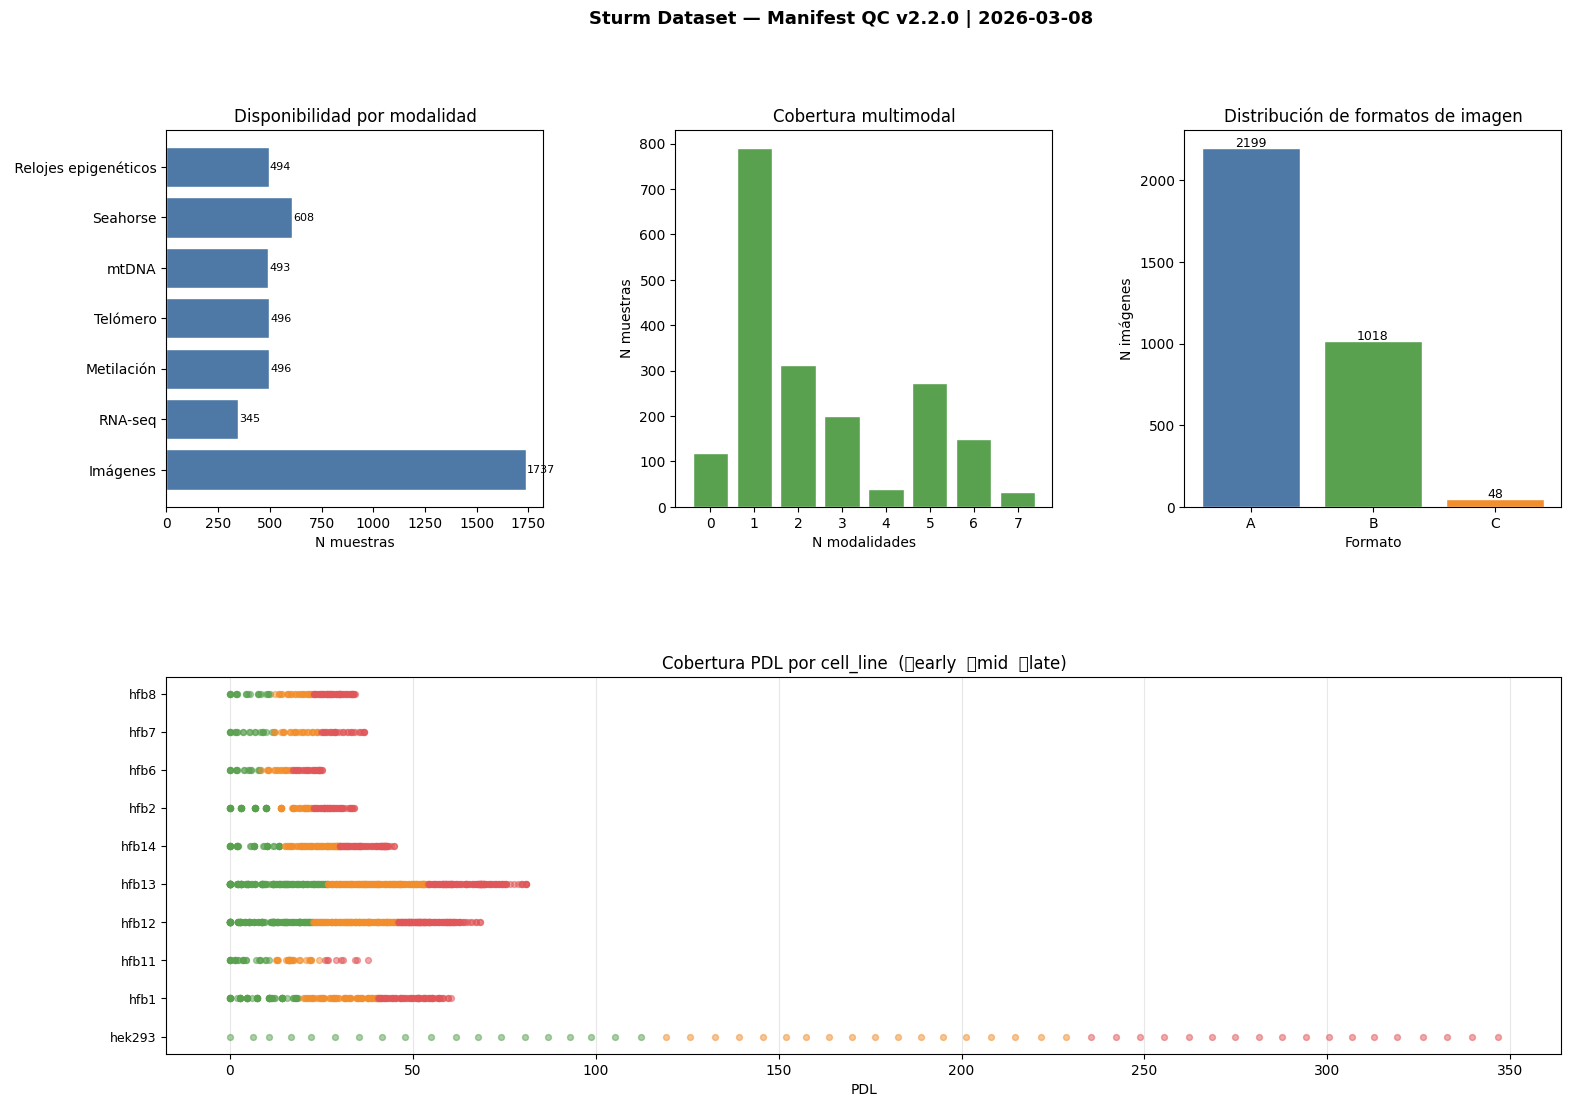

✅ QC guardado


In [9]:
# ── QC Visual ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'Sturm Dataset — Manifest QC v{PIPELINE_VERSION} | {RUN_DATE}', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Disponibilidad por modalidad
ax1 = fig.add_subplot(gs[0, 0])
flag_lp = [(f,l) for f,l in modality_flags if f in df_manifest.columns]
counts = [int(df_manifest[f].sum()) for f,_ in flag_lp]
labels_s = [l.split(' ',1)[1] for _,l in flag_lp]
ax1.barh(labels_s, counts, color='#4e79a7', edgecolor='white')
ax1.set_xlabel('N muestras'); ax1.set_title('Disponibilidad por modalidad')
for i,c in enumerate(counts): ax1.text(c+5, i, str(c), va='center', fontsize=8)

# 2. Cobertura multimodal
ax2 = fig.add_subplot(gs[0, 1])
mod_dist = df_manifest['n_modalities'].value_counts().sort_index()
ax2.bar(mod_dist.index.astype(str), mod_dist.values, color='#59a14f', edgecolor='white')
ax2.set_xlabel('N modalidades'); ax2.set_ylabel('N muestras')
ax2.set_title('Cobertura multimodal')

# 3. Formatos de imagen detectados
ax3 = fig.add_subplot(gs[0, 2])
fmt_dist = df_imgs['img_format'].value_counts()
colors_fmt = {'A':'#4e79a7','B':'#59a14f','C':'#f28e2b','D':'#aaa','SKIP':'#e15759'}
ax3.bar(fmt_dist.index, fmt_dist.values,
        color=[colors_fmt.get(f,'#888') for f in fmt_dist.index], edgecolor='white')
ax3.set_xlabel('Formato'); ax3.set_ylabel('N imágenes')
ax3.set_title('Distribución de formatos de imagen')
for i,(fmt,n) in enumerate(fmt_dist.items()): ax3.text(i, n+5, str(n), ha='center', fontsize=9)

# 4. PDL por donante
ax4 = fig.add_subplot(gs[1, :])
cell_lines = sorted(df_manifest['cell_line_key'].dropna().unique())
bin_colors = {'early':'#59a14f','mid':'#f28e2b','late':'#e15759'}
for i, cl in enumerate(cell_lines):
    sub = df_manifest[(df_manifest['cell_line_key']==cl) & df_manifest['pdl'].notna()]
    if len(sub)==0: continue
    for bn, bc in bin_colors.items():
        b = sub[sub['pdl_bin']==bn] if 'pdl_bin' in sub else sub
        ax4.scatter(b['pdl'], [i]*len(b), s=18, color=bc, alpha=0.5, zorder=3)
ax4.set_yticks(range(len(cell_lines)))
ax4.set_yticklabels(cell_lines, fontsize=9)
ax4.set_xlabel('PDL')
ax4.set_title('Cobertura PDL por cell_line  (🟢early  🟠mid  🔴late)')
ax4.grid(axis='x', alpha=0.3)

plt.savefig(OUTPUT_DIR/'reports'/f'qc_v{PIPELINE_VERSION}_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ QC guardado')